# 1. Data Understanding

## 1.1 Membaca Dataset

Pada tahap ini, dataset hasil crawling berita Sport dan Finance dibaca menggunakan library `pandas`. Dataset yang digunakan adalah `dataset_berita.csv`.

Data kemudian disimpan ke dalam variabel `df` dalam bentuk DataFrame agar lebih mudah diperiksa dan diolah pada tahap berikutnya.

In [4]:
import pandas as pd

# Membaca dataset hasil crawling
df = pd.read_csv("dataset_berita.csv")

# Menampilkan 5 data pertama
df.head()

,id,isi_berita,label
0,1,Jakarta - Putri Kusuma Wardani percaya diri de...,sport
1,2,Jakarta - Mata Derrick Michael Xzavierro berbi...,sport
2,3,Jakarta - Marc Marquez masih harus beradaptasi...,sport
3,4,Jakarta - Momen debut di Asian Games 2026 tak ...,sport
4,5,Jakarta - MotoGP 2026 akan berlanjut ke San Ma...,sport


## 1.2 Melihat Struktur Dataset

dilakukan pengecekan struktur dataset untuk mengetahui jumlah baris dan kolom yang tersedia. Informasi ini digunakan untuk melihat bentuk awal data sebelum masuk ke tahap preprocessing.

Selain itu, nama kolom dan tipe data setiap kolom juga dapat dilihat untuk mengetahui jenis data yang digunakan.

In [5]:
# Melihat ukuran dataset
print("Ukuran dataset:", df.shape)

# Melihat informasi setiap kolom
df.info()

Ukuran dataset: (200, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    int64 
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
dtypes: int64(1), object(2)
memory usage: 4.8+ KB


## 1.3 Mengecek Jumlah Data

Pada tahap ini, jumlah seluruh berita yang terdapat dalam dataset dihitung. Pengecekan ini dilakukan untuk memastikan data yang berhasil dikumpulkan sesuai dengan jumlah data yang ditargetkan pada proses crawling.

In [6]:
# Menampilkan jumlah seluruh data
print("Jumlah seluruh data:", len(df))

Jumlah seluruh data: 200


## 1.4 Melihat Distribusi Label
jumlah berita berdasarkan kategorinya dihitung menggunakan kolom `label`. Dataset terdiri dari dua kategori berita, yaitu `sport` dan `finance`.

Pengecekan ini dilakukan untuk mengetahui apakah jumlah data pada setiap kategori sudah sesuai.

In [7]:
# Menghitung jumlah data berdasarkan label
print(df["label"].value_counts())

label
sport      100
finance    100
Name: count, dtype: int64


## 1.5 Menampilkan Contoh Data
 beberapa data dari masing-masing kategori ditampilkan untuk melihat isi berita yang berhasil dikumpulkan.

Data yang ditampilkan terdiri dari `id`, `isi_berita`, dan `label`. Contoh data ini digunakan untuk melihat kondisi teks sebelum dilakukan preprocessing.

In [8]:
print("===== 5 DATA SPORT =====")

display(
    df[df["label"] == "sport"][
        ["id", "isi_berita", "label"]
    ].head(5)
)

print("\n===== 5 DATA FINANCE =====")

display(
    df[df["label"] == "finance"][
        ["id", "isi_berita", "label"]
    ].head(5)
)

===== 5 DATA SPORT =====


,id,isi_berita,label
0,1,Jakarta - Putri Kusuma Wardani percaya diri de...,sport
1,2,Jakarta - Mata Derrick Michael Xzavierro berbi...,sport
2,3,Jakarta - Marc Marquez masih harus beradaptasi...,sport
3,4,Jakarta - Momen debut di Asian Games 2026 tak ...,sport
4,5,Jakarta - MotoGP 2026 akan berlanjut ke San Ma...,sport



===== 5 DATA FINANCE =====


,id,isi_berita,label
100,101,Jakarta - Menteri Keuangan (Menkeu) Purbaya Yu...,finance
101,102,Jakarta - Semua masyarakat akan memiliki reken...,finance
102,103,"Jakarta - Perdana Menteri (PM) Singapura, Lawr...",finance
103,104,Jakarta - Harga emas Antam terus mengalami pen...,finance
104,105,"Jakarta - Penyedia kontrol lalu lintas udara, ...",finance


## 1.6 Mengecek Data Kosong

Pada tahap ini, dilakukan pengecekan terhadap data yang memiliki nilai kosong atau `NaN`. Data kosong perlu diketahui sebelum preprocessing karena dapat memengaruhi proses pengolahan teks.

In [9]:
# Mengecek jumlah data kosong pada setiap kolom
print(df.isnull().sum())

id            0
isi_berita    0
label         0
dtype: int64


## 1.7 Mengecek Data Duplikat

Pada tahap ini, dilakukan pengecekan terhadap data yang memiliki isi yang sama. Data duplikat perlu diperiksa agar satu berita tidak diproses lebih dari satu kali.

In [10]:
# Mengecek jumlah data duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


# 2. Data Preprocessing


## 2.1 Case Folding

Case folding dilakukan untuk mengubah seluruh huruf pada teks menjadi huruf kecil atau lowercase.

Tujuannya adalah agar kata yang sama tetapi memiliki perbedaan penggunaan huruf besar dan kecil dianggap sebagai kata yang sama. Contohnya, kata `Indonesia`, `INDONESIA`, dan `indonesia` akan menjadi `indonesia`.

In [11]:
# Mengubah seluruh teks menjadi huruf kecil
df["teks_case_folding"] = df["isi_berita"].str.lower()

# Menampilkan hasil
df[["isi_berita", "teks_case_folding"]].head()

,isi_berita,teks_case_folding
0,Jakarta - Putri Kusuma Wardani percaya diri de...,jakarta - putri kusuma wardani percaya diri de...
1,Jakarta - Mata Derrick Michael Xzavierro berbi...,jakarta - mata derrick michael xzavierro berbi...
2,Jakarta - Marc Marquez masih harus beradaptasi...,jakarta - marc marquez masih harus beradaptasi...
3,Jakarta - Momen debut di Asian Games 2026 tak ...,jakarta - momen debut di asian games 2026 tak ...
4,Jakarta - MotoGP 2026 akan berlanjut ke San Ma...,jakarta - motogp 2026 akan berlanjut ke san ma...


## 2.2 Cleaning Data

Cleaning dilakukan untuk membersihkan teks dari angka, tanda baca, URL, dan karakter yang tidak diperlukan.

Tahap ini bertujuan agar teks yang digunakan pada proses ekstraksi fitur hanya berisi kata-kata yang relevan.

In [12]:
import re

def cleaning(teks):
    # Menghapus URL
    teks = re.sub(r"http\S+|www\S+", " ", teks)

    # Menghapus angka
    teks = re.sub(r"\d+", " ", teks)

    # Menghapus tanda baca dan karakter selain huruf
    teks = re.sub(r"[^a-zA-Z\s]", " ", teks)

    # Menghapus spasi berlebih
    teks = re.sub(r"\s+", " ", teks).strip()

    return teks

df["teks_cleaning"] = df["teks_case_folding"].apply(cleaning)

df[["teks_case_folding", "teks_cleaning"]].head()

,teks_case_folding,teks_cleaning
0,jakarta - putri kusuma wardani percaya diri de...,jakarta putri kusuma wardani percaya diri deng...
1,jakarta - mata derrick michael xzavierro berbi...,jakarta mata derrick michael xzavierro berbina...
2,jakarta - marc marquez masih harus beradaptasi...,jakarta marc marquez masih harus beradaptasi d...
3,jakarta - momen debut di asian games 2026 tak ...,jakarta momen debut di asian games tak mau dis...
4,jakarta - motogp 2026 akan berlanjut ke san ma...,jakarta motogp akan berlanjut ke san marino se...


## 2.3 Tokenisasi

Tokenisasi merupakan proses memisahkan teks menjadi bagian-bagian yang lebih kecil berupa kata atau token.

Sebagai contoh, kalimat `tim indonesia memenangkan pertandingan` akan diubah menjadi beberapa token, yaitu `tim`, `indonesia`, `memenangkan`, dan `pertandingan`.

In [13]:
# Memisahkan teks menjadi kata
df["tokens"] = df["teks_cleaning"].apply(lambda teks: teks.split())

# Menampilkan hasil tokenisasi
df[["teks_cleaning", "tokens"]].head()

,teks_cleaning,tokens
0,jakarta putri kusuma wardani percaya diri deng...,"[jakarta, putri, kusuma, wardani, percaya, dir..."
1,jakarta mata derrick michael xzavierro berbina...,"[jakarta, mata, derrick, michael, xzavierro, b..."
2,jakarta marc marquez masih harus beradaptasi d...,"[jakarta, marc, marquez, masih, harus, beradap..."
3,jakarta momen debut di asian games tak mau dis...,"[jakarta, momen, debut, di, asian, games, tak,..."
4,jakarta motogp akan berlanjut ke san marino se...,"[jakarta, motogp, akan, berlanjut, ke, san, ma..."


## 2.4 Stopword Removal

Stopword removal dilakukan untuk menghapus kata-kata umum yang sering muncul tetapi biasanya tidak memberikan informasi penting dalam analisis teks.

Contohnya seperti `yang`, `dan`, `di`, `ke`, `dari`, dan kata umum lainnya.

In [ ]:
%pip install nltk

In [15]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stopword_indonesia = set(
    stopwords.words("indonesian")
)

df["tokens_stopword"] = df["tokens"].apply(
    lambda tokens: [
        kata for kata in tokens
        if kata not in stopword_indonesia
    ]
)

df[["tokens", "tokens_stopword"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tokens,tokens_stopword
0,"[jakarta, putri, kusuma, wardani, percaya, dir...","[jakarta, putri, kusuma, wardani, percaya, kom..."
1,"[jakarta, mata, derrick, michael, xzavierro, b...","[jakarta, mata, derrick, michael, xzavierro, b..."
2,"[jakarta, marc, marquez, masih, harus, beradap...","[jakarta, marc, marquez, beradaptasi, kondisi,..."
3,"[jakarta, momen, debut, di, asian, games, tak,...","[jakarta, momen, debut, asian, games, disia, s..."
4,"[jakarta, motogp, akan, berlanjut, ke, san, ma...","[jakarta, motogp, berlanjut, san, marino, seri..."


In [16]:
from nltk.corpus import stopwords

stopword_indonesia = set(
    stopwords.words("indonesian")
)

print("Jumlah stopword:", len(stopword_indonesia))

Jumlah stopword: 757


## 2.5 Stemming

Stemming dilakukan untuk mengubah kata menjadi bentuk dasarnya. Pada tahap ini digunakan library Sastrawi yang menyediakan stemmer untuk Bahasa Indonesia.

Sebagai contoh, kata `berlari`, `lari`, dan `berlarian` dapat dikembalikan ke bentuk dasar `lari`.

Tahap stemming membantu mengurangi variasi kata sehingga kata yang memiliki bentuk berbeda tetapi berasal dari kata dasar yang sama dapat diperlakukan sebagai kata yang sama.

In [ ]:
%pip install Sastrawi

In [18]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    teks = " ".join(tokens)
    return stemmer.stem(teks)

df["teks_preprocessed"] = df["tokens_stopword"].apply(
    stemming
)

df[["isi_berita", "teks_preprocessed"]].head()

,isi_berita,teks_preprocessed
0,Jakarta - Putri Kusuma Wardani percaya diri de...,jakarta putri kusuma wardani percaya komposisi...
1,Jakarta - Mata Derrick Michael Xzavierro berbi...,jakarta mata derrick michael xzavierro binar b...
2,Jakarta - Marc Marquez masih harus beradaptasi...,jakarta marc marquez adaptasi kondisi lengan k...
3,Jakarta - Momen debut di Asian Games 2026 tak ...,jakarta momen debut asi games sia sia alwi far...
4,Jakarta - MotoGP 2026 akan berlanjut ke San Ma...,jakarta motogp lanjut san marino seri musim ge...


# 3. Ekstraksi Fitur


Pada tahap ini, seluruh kata yang terdapat pada dokumen berita setelah preprocessing diekstrak menggunakan `CountVectorizer` dari library `scikit-learn`.

Kata-kata yang ditemukan akan menjadi fitur atau vocabulary yang digunakan pada proses representasi TF-IDF.

Setiap kata yang berbeda akan menjadi satu fitur dalam dataset.

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_count = vectorizer.fit_transform(
    df["teks_preprocessed"]
)

kata_unik = vectorizer.get_feature_names_out()

# Membuat tabel seluruh kata unik
df_kata_unik = pd.DataFrame({
    "No": range(1, len(kata_unik) + 1),
    "Kata Unik": kata_unik
})

# Menampilkan jumlah kata unik
print("Jumlah kata unik:", len(kata_unik))

# Menampilkan tabel kata unik
display(df_kata_unik)

Jumlah kata unik: 5154


,No,Kata Unik
0,1,aam
1,2,aan
2,3,abadi
3,4,abai
4,5,abal
...,...,...
5149,5150,zulfikri
5150,5151,zulhas
5151,5152,zulkifli
5152,5153,zurich


# 4. One-Hot Encoding

One-Hot Encoding digunakan untuk melihat representasi setiap kata dalam bentuk nilai 0 dan 1. Untuk memudahkan pembacaan, hasil yang ditampilkan hanya beberapa kata pertama.

In [37]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Mengambil 10 kata unik pertama untuk ditampilkan
kata_tampil = kata_unik[:10]

encoder = OneHotEncoder(
    sparse_output=False
)

one_hot = encoder.fit_transform(
    np.array(kata_tampil).reshape(-1, 1)
)

df_one_hot = pd.DataFrame(
    one_hot.astype(int),
    columns=kata_tampil,
    index=kata_tampil
)

df_one_hot.index.name = "Kata"

print("Jumlah seluruh kata unik:", len(kata_unik))
print("Jumlah kata yang ditampilkan:", len(kata_tampil))
print("Ukuran One-Hot Encoding:", one_hot.shape)

display(df_one_hot)

Jumlah seluruh kata unik: 5154
Jumlah kata yang ditampilkan: 10
Ukuran One-Hot Encoding: (10, 10)


,aam,aan,abadi,abai,abal,abang,abdukhodir,abdul,abdullah,aberdeen
Kata,,,,,,,,,,
aam,1,0,0,0,0,0,0,0,0,0
aan,0,1,0,0,0,0,0,0,0,0
abadi,0,0,1,0,0,0,0,0,0,0
abai,0,0,0,1,0,0,0,0,0,0
abal,0,0,0,0,1,0,0,0,0,0
abang,0,0,0,0,0,1,0,0,0,0
abdukhodir,0,0,0,0,0,0,1,0,0,0
abdul,0,0,0,0,0,0,0,1,0,0
abdullah,0,0,0,0,0,0,0,0,1,0


# 5. Bag of Words


Bag of Words digunakan untuk melihat jumlah kemunculan kata pada setiap berita. Hasil yang ditampilkan hanya beberapa berita dan beberapa kata agar tabel lebih mudah dibaca.

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_bow = vectorizer.fit_transform(
    df["teks_preprocessed"]
)

fitur_bow = vectorizer.get_feature_names_out()

# Menampilkan 10 berita dan 10 kata pertama
df_bow = pd.DataFrame(
    X_bow[:10, :10].toarray(),
    columns=fitur_bow[:10]
)

df_bow.insert(
    0,
    "id",
    df["id"].head(10).values
)

print("Jumlah berita:", X_bow.shape[0])
print("Jumlah fitur/kata:", X_bow.shape[1])
print("Ukuran matriks BoW:", X_bow.shape)

display(df_bow)

Jumlah berita: 200
Jumlah fitur/kata: 5154
Ukuran matriks BoW: (200, 5154)


,id,aam,aan,abadi,abai,abal,abang,abdukhodir,abdul,abdullah,aberdeen
0,1,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,0
5,6,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,0
7,8,0,0,0,0,0,0,0,0,0,0
8,9,0,0,0,0,0,0,0,0,0,0
9,10,0,0,0,0,0,0,0,0,0,0


# 6. Representasi TF-IDF


Pada tahap ini, setiap dokumen berita direpresentasikan dalam bentuk nilai TF-IDF.

TF-IDF digunakan untuk memberikan bobot pada setiap kata berdasarkan tingkat kepentingannya dalam sebuah dokumen.

Secara umum, nilai TF-IDF dihitung menggunakan:

$$
TFIDF(t,d) = TF(t,d) \times IDF(t)
$$

dengan:

- $TF(t,d)$ adalah frekuensi kemunculan kata $t$ pada dokumen $d$.
- $IDF(t)$ menunjukkan seberapa jarang kata tersebut muncul pada seluruh dokumen.
- $TFIDF(t,d)$ merupakan bobot akhir kata $t$ pada dokumen $d$.

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_tfidf = tfidf_vectorizer.fit_transform(
    df["teks_preprocessed"]
)

fitur_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Jumlah berita:", X_tfidf.shape[0])
print("Jumlah fitur/kata:", X_tfidf.shape[1])
print("Ukuran matriks TF-IDF:", X_tfidf.shape)

# Menampilkan data ID 101 sampai 120
df_tfidf = pd.DataFrame(
    X_tfidf[100:110, :10].toarray(),
    columns=fitur_tfidf[:10]
)

df_tfidf.insert(
    0,
    "id",
    df["id"].iloc[100:110].values
)

display(df_tfidf)

Jumlah berita: 200
Jumlah fitur/kata: 5154
Ukuran matriks TF-IDF: (200, 5154)


,id,aam,aan,abadi,abai,abal,abang,abdukhodir,abdul,abdullah,aberdeen
0,101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.048737
5,106,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
6,107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
7,108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
8,109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
9,110,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [66]:
# Membuat DataFrame dari hasil TF-IDF
df_tfidf_lengkap = pd.DataFrame(
    X_tfidf.toarray(),
    columns=fitur_tfidf
)

# Menambahkan ID jika belum ada
if "id" not in df_tfidf_lengkap.columns:
    df_tfidf_lengkap.insert(
        0,
        "id",
        df["id"].values
    )

# Menambahkan label jika belum ada
if "label" not in df_tfidf_lengkap.columns:
    df_tfidf_lengkap["label"] = df["label"].values

# Menyimpan hasil TF-IDF
df_tfidf_lengkap.to_csv(
    "hasil_tfidf.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Hasil TF-IDF berhasil disimpan.")
print("Nama file: hasil_tfidf.csv")
print("Ukuran data:", df_tfidf_lengkap.shape)

Hasil TF-IDF berhasil disimpan.
Nama file: hasil_tfidf.csv
Ukuran data: (200, 5155)


# 7. Reduksi Dimensi dengan PCA



## 7.1 Menyiapkan Data TF-IDF

Pada tahap sebelumnya, setiap berita telah direpresentasikan dalam bentuk TF-IDF. Hasil tersebut memiliki jumlah fitur yang cukup banyak karena setiap kata unik menjadi sebuah fitur.

Data TF-IDF kemudian digunakan sebagai input untuk proses reduksi dimensi menggunakan Principal Component Analysis (PCA).

In [51]:
# Mengubah sparse matrix menjadi array
X_tfidf_dense = X_tfidf.toarray()

print("Ukuran data TF-IDF:", X_tfidf_dense.shape)

Ukuran data TF-IDF: (200, 5154)


## 7.2 Menerapkan PCA

PCA digunakan untuk mengurangi jumlah dimensi pada data TF-IDF dengan mempertahankan variasi atau informasi utama yang terdapat pada data.

Pada tahap ini, jumlah komponen PCA tidak langsung ditentukan menjadi 2. Seluruh komponen terlebih dahulu dihitung untuk melihat seberapa besar variasi data yang dapat dijelaskan oleh masing-masing komponen.

In [30]:
from sklearn.decomposition import PCA

# Membuat PCA tanpa menentukan jumlah komponen
pca = PCA()

# Menerapkan PCA
X_pca = pca.fit_transform(X_tfidf_dense)

print("Ukuran data sebelum PCA :", X_tfidf_dense.shape)
print("Ukuran data setelah PCA :", X_pca.shape)

Ukuran data sebelum PCA : (200, 5154)
Ukuran data setelah PCA : (200, 200)


## 7.3 Melihat Explained Variance

Explained variance digunakan untuk mengetahui seberapa besar variasi data yang dapat dijelaskan oleh setiap komponen utama.

Nilai yang lebih besar menunjukkan bahwa komponen tersebut mampu menjelaskan variasi data yang lebih besar.

In [31]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance setiap komponen:")

for i, nilai in enumerate(
    explained_variance,
    start=1
):
    print(
        f"Komponen {i}: {nilai:.6f} "
        f"({nilai * 100:.2f}%)"
    )

Explained variance setiap komponen:
Komponen 1: 0.032560 (3.26%)
Komponen 2: 0.026883 (2.69%)
Komponen 3: 0.024980 (2.50%)
Komponen 4: 0.021455 (2.15%)
Komponen 5: 0.020064 (2.01%)
Komponen 6: 0.019614 (1.96%)
Komponen 7: 0.016114 (1.61%)
Komponen 8: 0.015534 (1.55%)
Komponen 9: 0.014853 (1.49%)
Komponen 10: 0.014383 (1.44%)
Komponen 11: 0.013566 (1.36%)
Komponen 12: 0.012037 (1.20%)
Komponen 13: 0.011697 (1.17%)
Komponen 14: 0.011498 (1.15%)
Komponen 15: 0.011333 (1.13%)
Komponen 16: 0.011242 (1.12%)
Komponen 17: 0.010947 (1.09%)
Komponen 18: 0.010733 (1.07%)
Komponen 19: 0.009910 (0.99%)
Komponen 20: 0.009821 (0.98%)
Komponen 21: 0.009446 (0.94%)
Komponen 22: 0.009085 (0.91%)
Komponen 23: 0.008893 (0.89%)
Komponen 24: 0.008736 (0.87%)
Komponen 25: 0.008417 (0.84%)
Komponen 26: 0.008292 (0.83%)
Komponen 27: 0.007901 (0.79%)
Komponen 28: 0.007786 (0.78%)
Komponen 29: 0.007536 (0.75%)
Komponen 30: 0.007392 (0.74%)
Komponen 31: 0.007366 (0.74%)
Komponen 32: 0.007323 (0.73%)
Komponen 33: 

## 7.4 Menghitung Cumulative Explained Variance

Cumulative explained variance digunakan untuk melihat jumlah informasi yang dapat dipertahankan jika beberapa komponen utama digabungkan.

Dengan cumulative explained variance, jumlah komponen yang diperlukan untuk mempertahankan sebagian besar informasi dari data dapat ditentukan.

In [32]:
import numpy as np

cumulative_variance = np.cumsum(
    explained_variance
)

print("Cumulative explained variance:")

for i, nilai in enumerate(
    cumulative_variance,
    start=1
):
    print(
        f"Komponen {i}: "
        f"{nilai:.4f} "
        f"({nilai * 100:.2f}%)"
    )

Cumulative explained variance:
Komponen 1: 0.0326 (3.26%)
Komponen 2: 0.0594 (5.94%)
Komponen 3: 0.0844 (8.44%)
Komponen 4: 0.1059 (10.59%)
Komponen 5: 0.1259 (12.59%)
Komponen 6: 0.1456 (14.56%)
Komponen 7: 0.1617 (16.17%)
Komponen 8: 0.1772 (17.72%)
Komponen 9: 0.1921 (19.21%)
Komponen 10: 0.2064 (20.64%)
Komponen 11: 0.2200 (22.00%)
Komponen 12: 0.2320 (23.20%)
Komponen 13: 0.2437 (24.37%)
Komponen 14: 0.2552 (25.52%)
Komponen 15: 0.2666 (26.66%)
Komponen 16: 0.2778 (27.78%)
Komponen 17: 0.2888 (28.88%)
Komponen 18: 0.2995 (29.95%)
Komponen 19: 0.3094 (30.94%)
Komponen 20: 0.3192 (31.92%)
Komponen 21: 0.3287 (32.87%)
Komponen 22: 0.3378 (33.78%)
Komponen 23: 0.3466 (34.66%)
Komponen 24: 0.3554 (35.54%)
Komponen 25: 0.3638 (36.38%)
Komponen 26: 0.3721 (37.21%)
Komponen 27: 0.3800 (38.00%)
Komponen 28: 0.3878 (38.78%)
Komponen 29: 0.3953 (39.53%)
Komponen 30: 0.4027 (40.27%)
Komponen 31: 0.4101 (41.01%)
Komponen 32: 0.4174 (41.74%)
Komponen 33: 0.4246 (42.46%)
Komponen 34: 0.4317 (43.

## 7.5 Menentukan Jumlah Komponen

Jumlah komponen ditentukan berdasarkan cumulative explained variance. Pada proses ini digunakan batas 95% untuk melihat berapa banyak komponen utama yang diperlukan agar sebagian besar variasi data tetap dipertahankan.

Dengan cara ini, jumlah komponen tidak ditentukan secara sembarang, tetapi berdasarkan karakteristik data hasil TF-IDF.

In [33]:
target_variance = 0.95

jumlah_komponen = np.argmax(
    cumulative_variance >= target_variance
) + 1

print(
    f"Jumlah komponen untuk "
    f"mempertahankan {target_variance * 100:.0f}% "
    f"variance:",
    jumlah_komponen
)

Jumlah komponen untuk mempertahankan 95% variance: 160


## 7.6 Melakukan Reduksi Dimensi

Setelah jumlah komponen ditentukan berdasarkan cumulative explained variance, PCA diterapkan kembali menggunakan jumlah komponen tersebut.

Hasilnya kemudian dibandingkan dengan jumlah fitur sebelum PCA untuk melihat seberapa besar reduksi dimensi yang dilakukan.

In [34]:
pca_final = PCA(
    n_components=jumlah_komponen
)

X_pca_final = pca_final.fit_transform(
    X_tfidf_dense
)

print(
    "Ukuran sebelum PCA :",
    X_tfidf_dense.shape
)

print(
    "Ukuran setelah PCA :",
    X_pca_final.shape
)

print(
    "Jumlah kolom sebelum PCA :",
    X_tfidf_dense.shape[1]
)

print(
    "Jumlah kolom setelah PCA :",
    X_pca_final.shape[1]
)

Ukuran sebelum PCA : (200, 5154)
Ukuran setelah PCA : (200, 160)
Jumlah kolom sebelum PCA : 5154
Jumlah kolom setelah PCA : 160


In [67]:
# Membuat nama kolom untuk setiap komponen PCA
nama_komponen = [
    f"PC{i}"
    for i in range(1, jumlah_komponen + 1)
]

# Mengubah hasil PCA menjadi DataFrame
df_pca = pd.DataFrame(
    X_pca_final,
    columns=nama_komponen
)

# Menambahkan ID dan label
df_pca.insert(
    0,
    "id",
    df["id"].values
)

df_pca["label"] = df["label"].values

# Menampilkan tabel hasil PCA
display(df_pca)

# Menyimpan hasil PCA ke CSV
df_pca.to_csv(
    "hasil_pca.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Hasil PCA berhasil disimpan.")
print("Nama file: hasil_pca.csv")
print("Ukuran data:", df_pca.shape)

,id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC152,PC153,PC154,PC155,PC156,PC157,PC158,PC159,PC160,label
0,1,0.019384,0.463168,-0.147316,0.063406,-0.036620,0.023040,0.047794,0.000258,-0.013118,...,-0.042931,-0.034029,0.028741,0.025326,0.011930,-0.007979,-0.006342,-0.041714,-0.019932,sport
1,2,0.014593,0.526455,-0.185382,0.083944,-0.028059,0.063966,0.068710,0.011619,-0.013685,...,0.049460,0.064438,-0.088816,0.009965,-0.045743,0.048812,0.026757,0.023218,-0.045622,sport
2,3,-0.033623,0.032312,0.300234,0.180924,-0.025382,0.071693,0.034067,0.017651,-0.176063,...,0.031957,-0.016494,0.007204,0.003150,0.006367,-0.002609,-0.054698,-0.002118,0.083554,sport
3,4,0.024718,0.425306,-0.117164,0.070607,-0.040539,0.030150,0.034791,-0.006646,-0.018409,...,0.014165,0.014179,-0.068519,-0.008080,-0.015166,0.024854,0.003032,0.021821,0.037845,sport
4,5,-0.098930,0.016066,0.568474,0.407086,-0.031882,0.121592,0.115481,0.026670,-0.184793,...,-0.020729,-0.052720,-0.069886,-0.046552,-0.078790,0.133157,-0.192460,0.159632,-0.020090,sport
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,0.027757,0.002326,0.051794,-0.121951,-0.033033,0.001546,-0.140028,-0.084296,-0.056888,...,-0.001812,-0.017542,0.016854,-0.024955,0.044173,-0.025691,0.016144,-0.003973,-0.007910,finance
196,197,0.096731,-0.032735,0.013086,-0.075963,-0.046102,-0.005666,-0.049557,-0.030683,-0.021015,...,0.025907,-0.025236,-0.020001,-0.021024,-0.019847,-0.005334,-0.006161,0.009078,0.002904,finance
197,198,0.085754,-0.040227,0.048289,-0.140629,-0.069266,-0.010207,-0.103598,-0.075392,-0.045822,...,-0.042564,-0.008937,-0.020109,0.021367,0.014306,-0.008073,-0.017521,-0.006779,-0.004135,finance
198,199,0.240581,-0.135719,-0.059974,-0.013798,-0.050597,-0.014599,0.269150,0.095469,0.046739,...,0.041767,-0.017191,0.013682,-0.006029,-0.065631,-0.021054,-0.017614,-0.015746,-0.018421,finance


Hasil PCA berhasil disimpan.
Nama file: hasil_pca.csv
Ukuran data: (200, 162)


# 8. Visualisasi Data Hasil PCA



## 8.1 Menyiapkan Data Hasil PCA

Hasil reduksi dimensi dari PCA disimpan ke dalam DataFrame bersama dengan label berita. Data ini digunakan untuk membuat visualisasi persebaran berita Sport dan Finance.

In [27]:
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

df_pca["label"] = df["label"].values

df_pca.head()

,PC1,PC2,label
0,0.019438,0.462864,sport
1,0.014617,0.526227,sport
2,-0.033595,0.032394,sport
3,0.024731,0.425172,sport
4,-0.098901,0.016148,sport


## 8.2 Visualisasi Hasil PCA

Setelah proses TF-IDF, jumlah fitur yang digunakan menjadi cukup banyak karena setiap kata unik menjadi fitur. PCA dapat digunakan untuk menyederhanakan data tersebut sehingga pola antarberita lebih mudah dilihat.

Pada tahap visualisasi, data direduksi menjadi dua komponen utama, yaitu PC1 dan PC2. PC1 digunakan sebagai sumbu X dan PC2 sebagai sumbu Y.

Penggunaan dua komponen pada tahap ini hanya untuk keperluan visualisasi. PCA utama tetap menggunakan jumlah komponen berdasarkan explained variance.

In [52]:
from sklearn.decomposition import PCA

# PCA khusus untuk visualisasi
pca_visual = PCA(n_components=2)

X_pca_visual = pca_visual.fit_transform(
    X_tfidf.toarray()
)

print("Ukuran data sebelum PCA:", X_tfidf.shape)
print("Ukuran data setelah PCA:", X_pca_visual.shape)

print(
    f"Variance PC1: "
    f"{pca_visual.explained_variance_ratio_[0] * 100:.2f}%"
)

print(
    f"Variance PC2: "
    f"{pca_visual.explained_variance_ratio_[1] * 100:.2f}%"
)

print(
    f"Total variance PC1 + PC2: "
    f"{pca_visual.explained_variance_ratio_.sum() * 100:.2f}%"
)

Ukuran data sebelum PCA: (200, 5154)
Ukuran data setelah PCA: (200, 2)
Variance PC1: 3.26%
Variance PC2: 2.69%
Total variance PC1 + PC2: 5.94%


In [68]:
df_pca_visual = pd.DataFrame(
    X_pca_visual,
    columns=["PC1", "PC2"]
)

df_pca_visual.insert(
    0,
    "id",
    df["id"].values
)

df_pca_visual["label"] = df["label"].values

# Menampilkan 20 data pertama
display(df_pca_visual.head(20))

# Menyimpan hasil PCA visualisasi ke CSV
df_pca_visual.to_csv(
    "hasil_pca_visualisasi.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Hasil PCA untuk visualisasi berhasil disimpan.")
print("Nama file: hasil_pca_visualisasi.csv")
print("Ukuran data:", df_pca_visual.shape)

,id,PC1,PC2,label
0,1,0.019384,0.462885,sport
1,2,0.014557,0.526188,sport
2,3,-0.033612,0.032370,sport
3,4,0.024712,0.425148,sport
4,5,-0.098965,0.016225,sport
5,6,0.007250,0.460461,sport
6,7,0.067077,0.599548,sport
7,8,0.120028,0.554547,sport
8,9,-0.194963,-0.019324,sport
9,10,-0.083083,-0.034426,sport


Hasil PCA untuk visualisasi berhasil disimpan.
Nama file: hasil_pca_visualisasi.csv
Ukuran data: (200, 4)


## 8.3 Scatter Plot Hasil PCA

Scatter plot digunakan untuk melihat persebaran berita berdasarkan dua komponen utama. Setiap titik pada grafik mewakili satu berita.

PC1 digunakan sebagai sumbu X dan PC2 digunakan sebagai sumbu Y. Warna pada grafik menunjukkan label berita, yaitu Sport dan Finance.

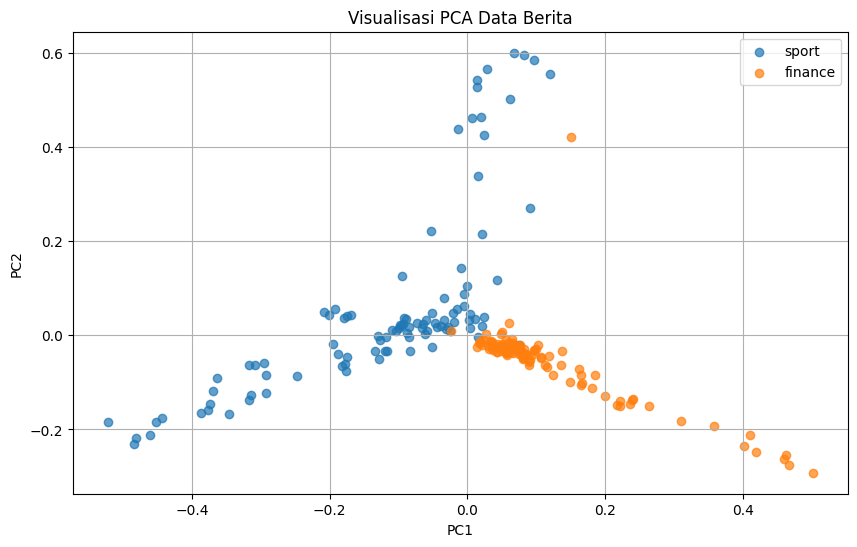

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for label in df_pca_visual["label"].unique():

    data = df_pca_visual[
        df_pca_visual["label"] == label
    ]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=label,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualisasi PCA Data Berita")
plt.legend()
plt.grid(True)

plt.show()

# 9. Perbandingan Hasil

## 9.1 Hasil TF-IDF

Hasil TF-IDF merupakan representasi data sebelum dilakukan reduksi dimensi. Setiap kata unik menjadi fitur sehingga jumlah kolom dapat menjadi sangat banyak. Nilai pada setiap kolom menunjukkan bobot suatu kata pada masing-masing berita.

Tabel berikut menampilkan sebagian data TF-IDF untuk melihat bentuk data sebelum dilakukan PCA.

In [ ]:
df_tfidf_tampil = pd.DataFrame(
    X_tfidf[:10, :10].toarray(),
    columns=fitur_tfidf[:10]
)

df_tfidf_tampil.insert(
    0,
    "id",
    df["id"].head(10).values
)

df_tfidf_tampil["label"] = df["label"].head(10).values

display(df_tfidf_tampil)

,id,aam,aan,abadi,abai,abal,abang,abdukhodir,abdul,abdullah,aberdeen,label
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
5,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
6,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
7,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
8,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport
9,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,sport


## 9.2 Hasil PCA

Setelah TF-IDF, dilakukan reduksi dimensi menggunakan PCA. Jumlah komponen pada tahap ini ditentukan berdasarkan cumulative explained variance sehingga jumlah komponen yang dihasilkan mengikuti karakteristik data.

Komponen yang dihasilkan oleh PCA bukan merupakan kata tertentu. Setiap komponen merupakan kombinasi matematis dari fitur-fitur TF-IDF.

Tabel berikut menampilkan hasil PCA setelah reduksi dimensi.

In [58]:
# Menampilkan hasil PCA utama
df_pca_tampil = pd.DataFrame(
    X_pca_final,
    columns=nama_komponen
)

df_pca_tampil.insert(
    0,
    "id",
    df["id"].values
)

df_pca_tampil["label"] = df["label"].values

display(df_pca_tampil.head(10))

print("Jumlah kolom sebelum PCA:", X_tfidf.shape[1])
print("Jumlah kolom setelah PCA:", X_pca_final.shape[1])

,id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC152,PC153,PC154,PC155,PC156,PC157,PC158,PC159,PC160,label
0,1,0.019384,0.463168,-0.147316,0.063406,-0.036620,0.023040,0.047794,0.000258,-0.013118,...,-0.042931,-0.034029,0.028741,0.025326,0.011930,-0.007979,-0.006342,-0.041714,-0.019932,sport
1,2,0.014593,0.526455,-0.185382,0.083944,-0.028059,0.063966,0.068710,0.011619,-0.013685,...,0.049460,0.064438,-0.088816,0.009965,-0.045743,0.048812,0.026757,0.023218,-0.045622,sport
2,3,-0.033623,0.032312,0.300234,0.180924,-0.025382,0.071693,0.034067,0.017651,-0.176063,...,0.031957,-0.016494,0.007204,0.003150,0.006367,-0.002609,-0.054698,-0.002118,0.083554,sport
3,4,0.024718,0.425306,-0.117164,0.070607,-0.040539,0.030150,0.034791,-0.006646,-0.018409,...,0.014165,0.014179,-0.068519,-0.008080,-0.015166,0.024854,0.003032,0.021821,0.037845,sport
4,5,-0.098930,0.016066,0.568474,0.407086,-0.031882,0.121592,0.115481,0.026670,-0.184793,...,-0.020729,-0.052720,-0.069886,-0.046552,-0.078790,0.133157,-0.192460,0.159632,-0.020090,sport
5,6,0.007289,0.460632,-0.147385,0.080229,0.001360,0.004237,0.052095,-0.022863,-0.026137,...,-0.024112,-0.038619,-0.045583,0.091813,-0.005717,0.005087,-0.039164,-0.036692,-0.000793,sport
6,7,0.067084,0.599672,-0.208325,0.102545,-0.070080,0.055987,0.050942,0.017920,-0.005810,...,0.013684,0.030304,-0.151372,-0.048916,-0.087903,0.061184,-0.069744,0.036559,-0.059809,sport
7,8,0.119995,0.554769,-0.228888,0.122534,-0.079584,0.076582,0.065939,0.034113,0.020755,...,-0.001165,-0.008979,-0.010252,0.014691,0.044409,0.002928,-0.009292,-0.002847,-0.027900,sport
8,9,-0.194949,-0.019185,-0.083001,0.014132,0.025543,-0.007538,-0.010252,0.150018,0.005925,...,0.012891,0.034597,-0.020537,0.078344,0.023298,-0.021275,0.046526,-0.001319,0.104764,sport
9,10,-0.083121,-0.033634,-0.010189,-0.037116,0.003362,0.012760,-0.074790,0.112073,0.004490,...,0.005442,0.027948,-0.012397,0.008307,0.004848,-0.024757,0.026029,0.027882,0.014115,sport


Jumlah kolom sebelum PCA: 5154
Jumlah kolom setelah PCA: 160


## 9.3 Hasil PCA untuk Visualisasi

Selain PCA utama, dilakukan PCA dengan dua komponen untuk kebutuhan visualisasi. Dua komponen tersebut adalah PC1 dan PC2 yang digunakan sebagai sumbu X dan Y pada scatter plot.

Penggunaan dua komponen pada tahap ini hanya bertujuan untuk menampilkan persebaran data dalam bentuk dua dimensi dan tidak menggantikan hasil PCA utama.

In [59]:
# Menampilkan hasil PCA khusus visualisasi
df_pca_visual_tampil = pd.DataFrame(
    X_pca_visual,
    columns=["PC1", "PC2"]
)

df_pca_visual_tampil.insert(
    0,
    "id",
    df["id"].values
)

df_pca_visual_tampil["label"] = df["label"].values

display(df_pca_visual_tampil.head(5))

,id,PC1,PC2,label
0,1,0.019384,0.462885,sport
1,2,0.014557,0.526188,sport
2,3,-0.033612,0.032370,sport
3,4,0.024712,0.425148,sport
4,5,-0.098965,0.016225,sport
